# Hierarchical Clustering

Hierarchical clustering is one of the most popular unsupervised learning algorithms used to group similar observations.

Unlike KMeans, Hierarchical clustering does not require specifying the number of cluster beforehand.
Instead, it creates a hierarchy of clusters represented using dendogram.

## Types of hierarchical clustering

- Agglomerative clustering(Bottom-Up approach)
- Divisive clustering(Top-Down approach)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering

In [2]:
iris = load_iris()

X = iris.data
print(X.shape)

(150, 4)


In [3]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(X)

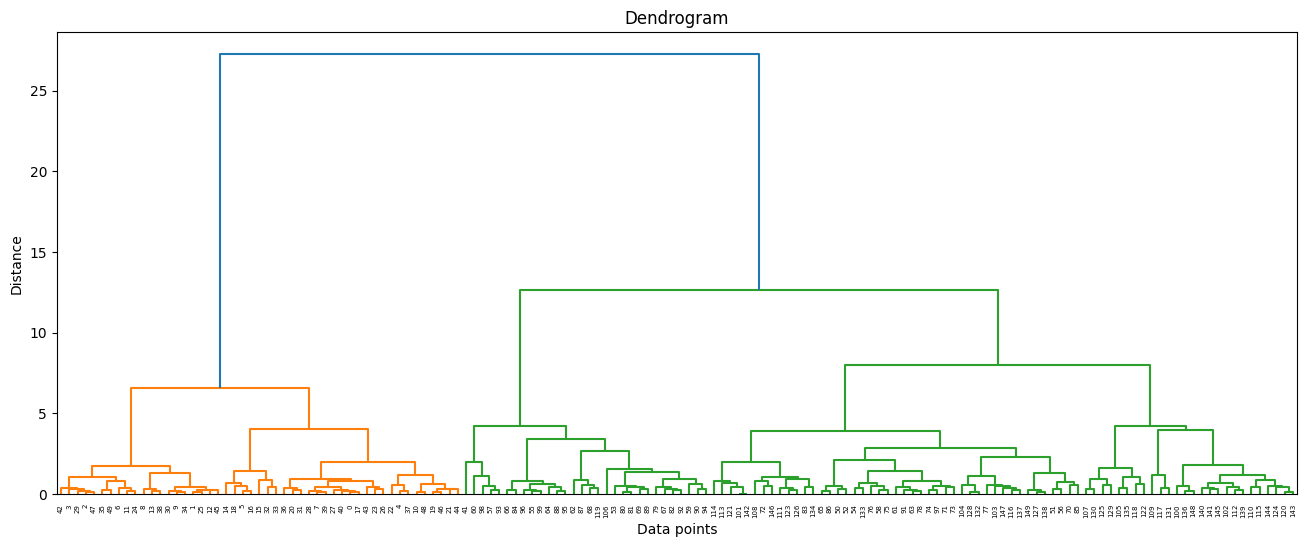

In [5]:
Z = linkage(
    x_scaled,
    method='ward'
)

plt.figure(figsize=(16,6))

dendrogram(Z)

plt.title("Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")

plt.show()

In [7]:
model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

labels = model.fit_predict(x_scaled)

labels


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### End to End code

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage,dendrogram

In [9]:
iris = load_iris()

X = iris.data

In [10]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(X)

In [13]:
Z = linkage(x_scaled,method='average')

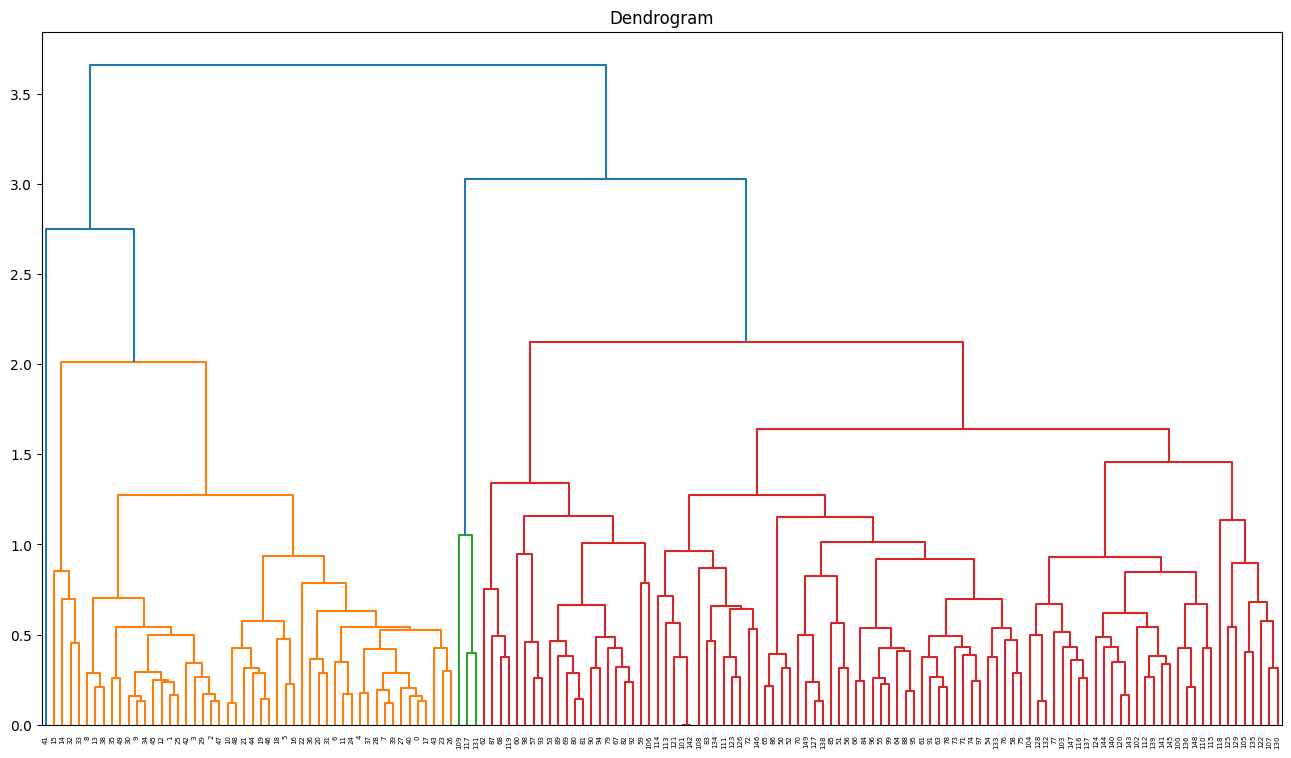

In [14]:
plt.figure(figsize=(16,9))

dendrogram(Z)

plt.title("Dendrogram")

plt.show()

In [15]:
model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = model.fit_predict(x_scaled)

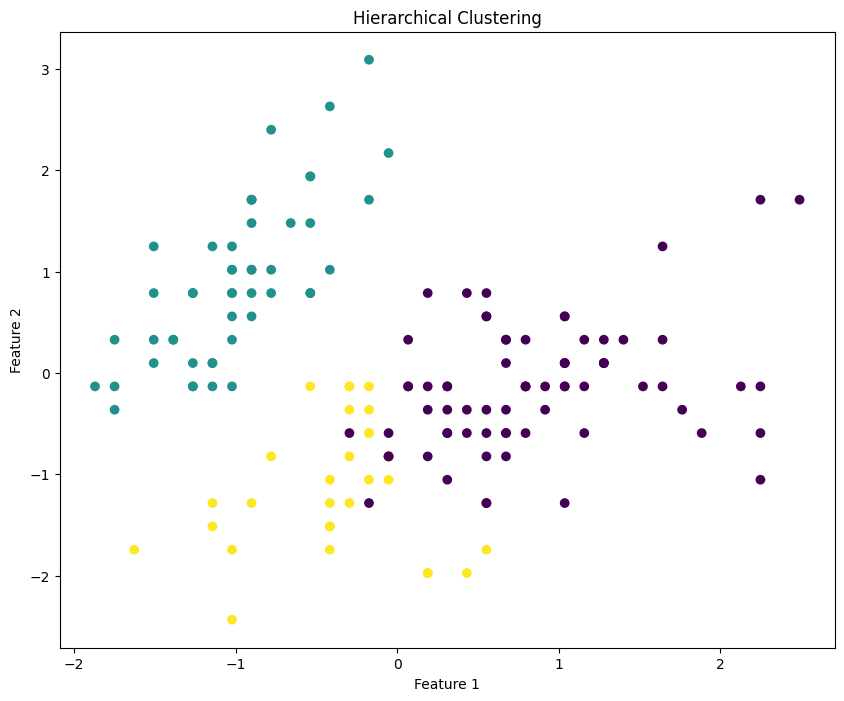

In [16]:
plt.figure(figsize=(10,8))

plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c = labels
)

plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Divisive Clustering

In [17]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()

X = iris.data

scaler = StandardScaler()

x = scaler.fit_transform(X)

### Divisive clustering function

In [21]:
import numpy as np
from sklearn.cluster import KMeans

def divisive_clustering(X,n_clusters):
    
    clusters = [np.arange(len(X))]
    
    while len(clusters) < n_clusters:
        
        #largest cluster
        largest_cluster = max(clusters,key=len)
        
        clusters.remove(largest_cluster)
        
        data = X[largest_cluster]
        
        kmeans = KMeans(
            n_clusters = 2,
            random_state=42,
            n_init = 10
        )
        
        labels = kmeans.fit_predict(data)
        
        cluster_1 = largest_cluster[labels==0]
        cluster_2 = largest_cluster[labels==1]
        
        clusters.append(cluster_1)
        clusters.append(cluster_2)
        
    final_labels = np.zeros(len(X))
    for idx,cluster in enumerate(clusters):
        final_labels[cluster] = idx
        
    return final_labels

In [22]:
labels = divisive_clustering(x,n_clusters=3)

print(labels)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 2. 2. 2. 1. 1. 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 2. 1.
 1. 1. 1. 2. 2. 2. 1. 1. 1. 1. 1. 1. 1. 2. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 2. 1. 2. 2. 2. 2. 1. 2. 2. 2. 2. 2. 2. 1. 1. 2. 2. 2. 2. 1.
 2. 1. 2. 1. 2. 2. 1. 2. 2. 2. 2. 2. 2. 1. 1. 2. 2. 2. 1. 2. 2. 2. 1. 2.
 2. 2. 1. 2. 2. 1.]


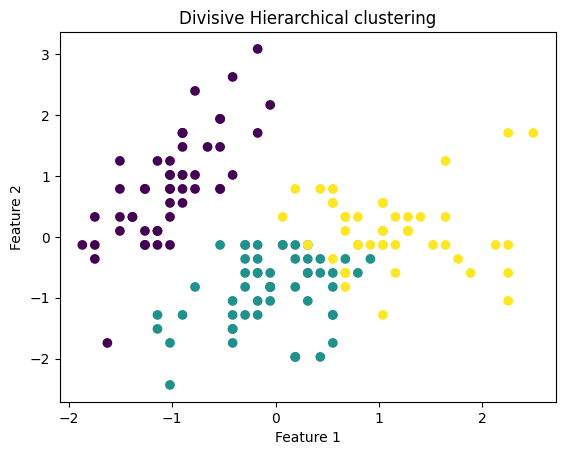

In [24]:
import matplotlib.pyplot as plt

plt.scatter(
    x[:,0],
    x[:,1],
    c = labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Divisive Hierarchical clustering")

plt.show()
